# Demo Notebook 3 — Grading & Evaluation

This notebook demonstrates how NeuroBench turns model answers into scores:

1. The **grading engine** (`grading/`) — exact / MCQ / numeric-tolerance / Jaccard partial credit / multi-part.
2. Scoring a **simulated model** over the full Category-3 set → an accuracy report with partial credit.
3. The same scoring inside the **Inspect harness** (`agent/`), producing trajectory logs.
4. A **model-vs-human** comparison table (with a clearly-labelled placeholder baseline) — the template for the final report.

## Setup

In [1]:
import pathlib
import sys

_here = pathlib.Path.cwd()
ROOT = next((p for p in [_here, *_here.parents] if (p / "pyproject.toml").exists()), _here)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from grading import core
from grading.numeric_tolerance import within_tolerance
from grading.partial_credit import jaccard, set_score
from benchmark import verify_ground_truth

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 4)

QUESTIONS = {q["id"]: q for q in verify_ground_truth.load_questions()}
ANSWERS = verify_ground_truth.load_answers()
print(f"{len(QUESTIONS)} questions, {len(ANSWERS)} answers")

20 questions, 20 answers


## 1. The grading modes

Answers are graded on the final result, not the path. Each mode is a small, deterministic, model-independent function.

In [2]:
choices = {"A": "awake", "B": "anesthetized"}
demo = [
    ("MCQ by letter", core.grade_mcq("B", "anesthetized", choices)),
    ("MCQ by value", core.grade_mcq("anesthetized", "anesthetized", choices)),
    ("MCQ wrong", core.grade_mcq("A", "anesthetized", choices)),
    ("exact (case-insensitive)", core.grade_exact("Awake ", "awake")),
    ("numeric within +/-120", within_tolerance("1650", 1684.09, 120.0)),
    ("numeric out of tol", within_tolerance("1000", 1684.09, 120.0)),
    ("Jaccard overlap 4/6", round(jaccard([1, 2, 3, 4], [3, 4, 5, 6]), 3)),
    ("set_score partial", set_score([1], [1, 2, 3, 4])),
]
pd.DataFrame(demo, columns=["grading mode", "result"])

,grading mode,result
0,MCQ by letter,True
1,MCQ by value,True
2,MCQ wrong,False
3,exact (case-insensitive),True
4,numeric within +/-120,True
5,numeric out of tol,False
6,Jaccard overlap 4/6,0.333
7,set_score partial,0.5


In [3]:
# Multi-part questions are scored per part and averaged (partial credit).
multi_q = QUESTIONS["C3-Q10"]
truth10 = ANSWERS["C3-Q10"]["answer"]
for label, ans in [
    ("both correct", {"state": "B", "band": "A"}),
    ("state only", {"state": "B", "band": "B"}),
    ("neither", {"state": "A", "band": "C"}),
]:
    r = core.grade_answer(multi_q, ans, truth10)
    print(f"{label:14s} -> score={r['score']:.2f}  parts={r['parts']}")

both correct   -> score=1.00  parts={'state': 1.0, 'band': 1.0}
state only     -> score=0.50  parts={'state': 1.0, 'band': 0.0}
neither        -> score=0.00  parts={'state': 0.0, 'band': 0.0}


## 2. Scoring a simulated model

We simulate a model's final answers (a strong model that misses one classification and gets half of the multi-part question) and grade the whole Category-3 set. In a real run these answers come from the agent; here they are fixed so the demo is deterministic.

In [4]:
simulated = {
    "C3-Q01": "awake",
    "C3-Q02": "anesthetized",
    "C3-Q03": "awake",
    "C3-Q04": "awake",          # miss (truth: anesthetized)
    "C3-Q05": "awake",
    "C3-Q06": "anesthetized",
    "C3-Q07": "awake",
    "C3-Q08": "anesthetized",
    "C3-Q09": "1650",           # within +/-120 of 1684.09
    "C3-Q10": {"state": "anesthetized", "band": "theta"},  # band wrong -> 0.5
}

# Iterate over the simulated answers (this demo focuses on Category 3).
rows = []
for qid, model_answer in simulated.items():
    q = QUESTIONS[qid]
    truth = ANSWERS[qid]["answer"]
    result = core.grade_answer(q, model_answer, truth)
    rows.append({
        "id": qid,
        "type": q["answer_type"],
        "model": str(model_answer),
        "truth": str(truth),
        "score": result["score"],
        "passed": result["passed"],
    })
results = pd.DataFrame(rows)
results

,id,type,model,truth,score,passed
0,C3-Q01,mcq,awake,awake,1.0,True
1,C3-Q02,mcq,anesthetized,anesthetized,1.0,True
2,C3-Q03,mcq,awake,awake,1.0,True
3,C3-Q04,mcq,awake,anesthetized,0.0,False
4,C3-Q05,mcq,awake,awake,1.0,True
5,C3-Q06,mcq,anesthetized,anesthetized,1.0,True
6,C3-Q07,mcq,awake,awake,1.0,True
7,C3-Q08,mcq,anesthetized,anesthetized,1.0,True
8,C3-Q09,numeric,1650,1684.09,1.0,True
9,C3-Q10,multi,"{'state': 'anesthetized', 'band': 'theta'}","{'band': 'delta', 'state': 'anesthetized'}",0.5,False


overall accuracy (with partial credit): 85.00%

by answer type:
type
mcq        0.875
multi      0.500
numeric    1.000


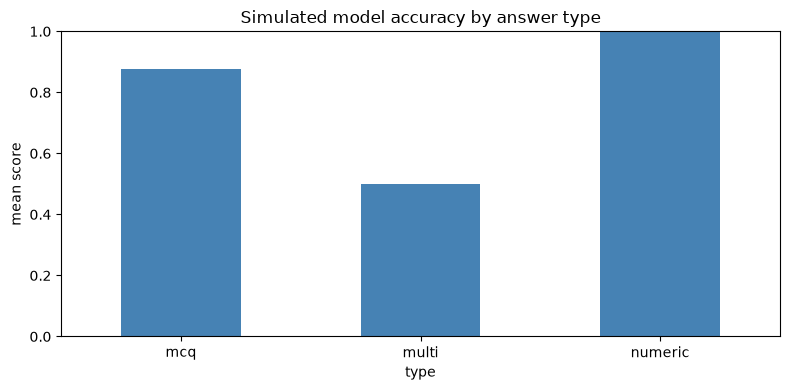

In [5]:
overall = results["score"].mean()
by_type = results.groupby("type")["score"].mean()
print(f"overall accuracy (with partial credit): {overall:.2%}")
print("\nby answer type:")
print(by_type.to_string())

by_type.plot(kind="bar", color="steelblue", ylim=(0, 1))
plt.ylabel("mean score")
plt.title("Simulated model accuracy by answer type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. The same scoring inside the Inspect harness

The production path runs each question through the Inspect `react` agent and scores it with `neurobench_scorer`, which wraps the exact grading engine above. Here we run one sample offline with a scripted mock model to show the harness produces the same score and a structured log.

In [6]:
from inspect_ai import Task
from inspect_ai import eval as inspect_eval
from inspect_ai.model import ModelOutput, get_model
from inspect_ai.solver import generate

from agent.dataset import neurobench_dataset
from agent.scorers import neurobench_scorer
from agent.task import setup_context

sample = [s for s in neurobench_dataset(category=3) if s.id == "C3-Q02"]  # truth: anesthetized
task = Task(dataset=sample, solver=[setup_context(), generate()], scorer=neurobench_scorer())
model = get_model(
    "mockllm/model",
    custom_outputs=[ModelOutput.from_content("mockllm/model", "Spectral analysis shows delta dominance.\nANSWER: anesthetized")],
)
log = inspect_eval(task, model=model, display="none")[0]

score = list(log.samples[0].scores.values())[0]
print("status      :", log.status)
print("model answer:", score.answer)
print("score value :", score.value)
print("explanation :", score.explanation)
print("metrics     :", {m: round(v.value, 3) for m, v in log.results.scores[0].metrics.items()})

Output()

status      : success
model answer: anesthetized
score value : 1.0
explanation : expected='anesthetized' parts=None
metrics     : {'mean': 1.0, 'stderr': 0.0}


The harness score matches the grading-engine score for the same answer. Real runs produce a full `.eval` log per sample (every tool call and reasoning step), reviewable with `inspect view` — the trajectory data used for qualitative analysis in the final report.

## 4. Model-vs-human comparison (report template)

The final report compares models against each other and against a human baseline. Below is the table/plot structure, populated with the simulated model score and **placeholder** values for other models and the human baseline. These are illustrative only — real numbers come from Stage 9 runs (`inspect eval` per model; `human_cli` for the baseline).

In [7]:
comparison = pd.DataFrame(
    {
        "agent": ["Claude (this sim)", "GPT-4o (placeholder)", "Gemini (placeholder)", "Human (placeholder)"],
        "accuracy": [overall, 0.70, 0.65, 0.80],
        "is_placeholder": [False, True, True, True],
    }
)
comparison

,agent,accuracy,is_placeholder
0,Claude (this sim),0.85,False
1,GPT-4o (placeholder),0.70,True
2,Gemini (placeholder),0.65,True
3,Human (placeholder),0.80,True


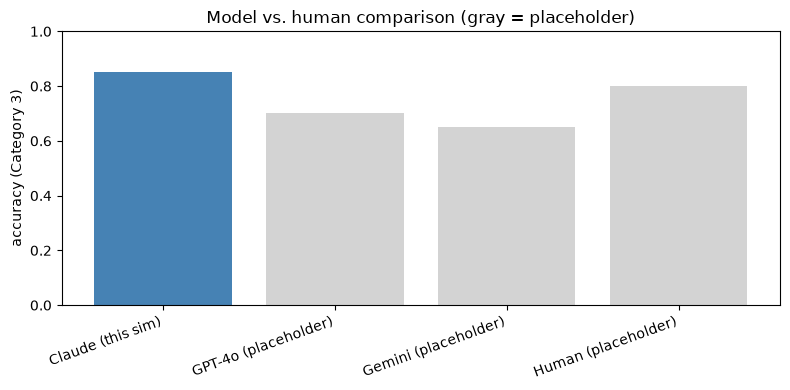

In [8]:
colors = ["steelblue" if not p else "lightgray" for p in comparison["is_placeholder"]]
plt.bar(comparison["agent"], comparison["accuracy"], color=colors)
plt.ylim(0, 1)
plt.ylabel("accuracy (Category 3)")
plt.title("Model vs. human comparison (gray = placeholder)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Next steps

- **Stage 9:** run `inspect eval agent/task.py --model <provider/model>` for Claude, GPT-4o, and Gemini (API keys in `.env`), and collect a human baseline via Inspect's `human_cli` on the same tasks/tools.
- **Stage 10:** read the `.eval` logs into `analysis/comparison_report.ipynb` to produce the accuracy-by-category/model tables, partial-credit breakdowns, and trajectory analysis — replacing the placeholder values above with real results.